<a href="https://colab.research.google.com/github/sredhalucca-hash/airline-passengers/blob/main/airline_passengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cudf
import cupy as cp

In [ ]:
!pip install cudf-cu12 cupy-cuda12x -q

        GPU EXPLORATORY DATA ANALYSIS

Dataset Loaded Successfully

Shape
(144, 2)

Columns
['Month', 'Passengers']

Data Types
Month         object
Passengers     int64
dtype: object

First Five Rows
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Last Five Rows
       Month  Passengers
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432

Random Sample
       Month  Passengers
121  1959-02         342
123  1959-04         396
30   1951-07         199
133  1960-02         391
95   1956-12         306

Summary Statistics
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000

Missing Values
Month         0
Passengers    0
dtype: int64

Duplicate Rows : 0

Unique Values
Month : 144
Passengers : 118

Categorical Columns

 

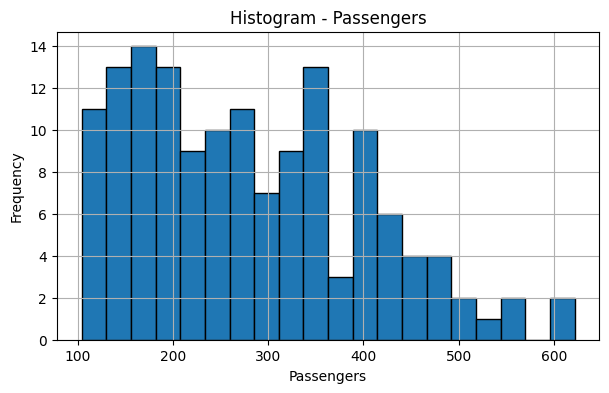


Generating Boxplots...


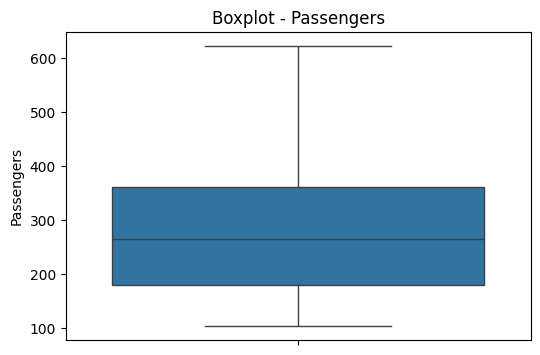

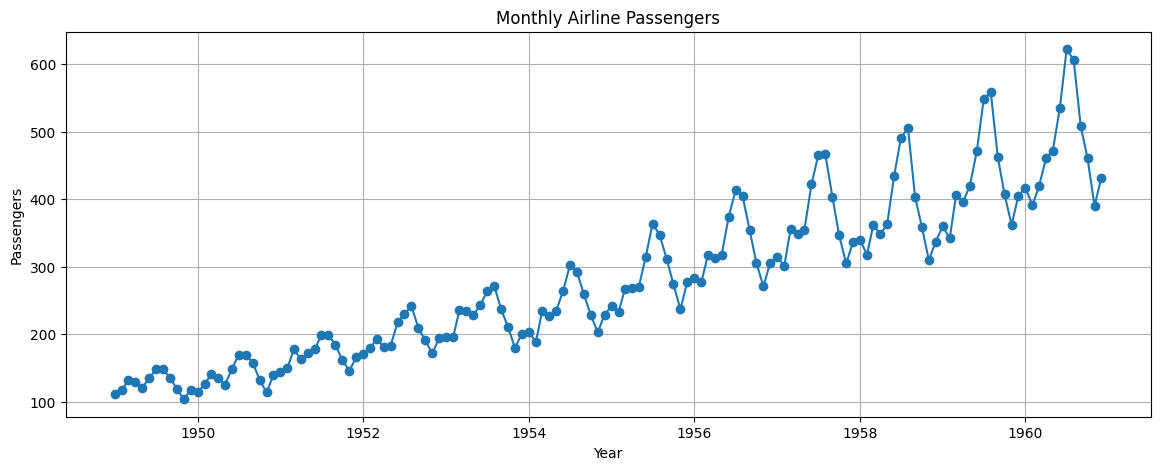

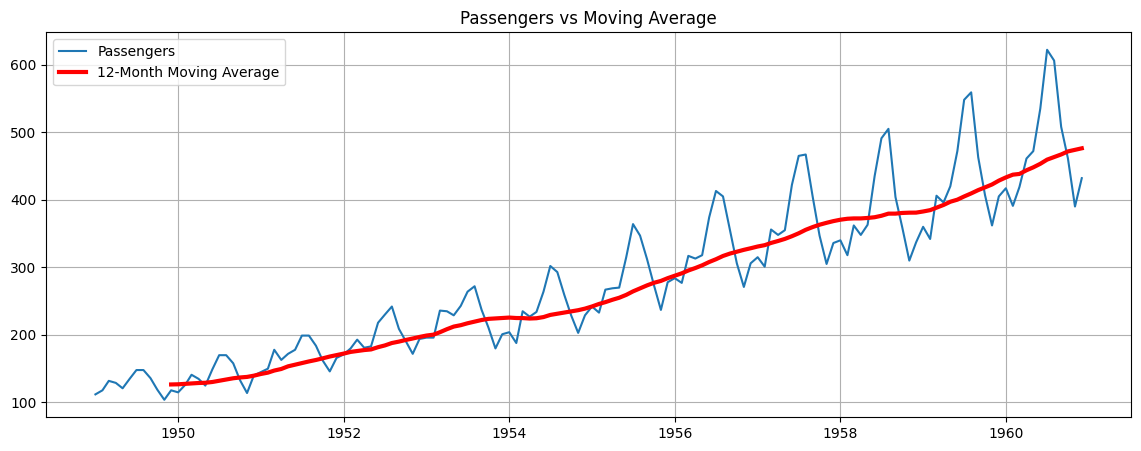


Outlier Detection
Passengers : 0 Outliers

Missing Percentage
Month             0.000000
Passengers        0.000000
Moving_Average    7.638889
dtype: float64

Memory Usage
Index             1152
Month             1152
Passengers        1152
Moving_Average    1152
dtype: int64

Clean Dataset Saved

GPU Information
GPU Name : Tesla T4
Total Memory (GB): 14.56

EDA COMPLETED SUCCESSFULLY


In [ ]:
# ==========================================================
# COMPLETE GPU EDA PROGRAM (Google Colab / Kaggle / DGX)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# GPU Libraries
import cudf
import cupy as cp

print("="*70)
print("        GPU EXPLORATORY DATA ANALYSIS")
print("="*70)

############################################################
# LOAD DATASET
############################################################

# Read Excel using pandas
pdf = pd.read_excel("/content/airline_passengers.xlsx")

# Convert to GPU DataFrame
try:
    gdf = cudf.from_pandas(pdf)
except:
    pdf.to_csv("/content/temp.csv", index=False)
    gdf = cudf.read_csv("/content/temp.csv")

print("\nDataset Loaded Successfully")

############################################################
# BASIC INFORMATION
############################################################

print("\nShape")
print(gdf.shape)

print("\nColumns")
print(list(gdf.columns))

print("\nData Types")
print(gdf.dtypes)

############################################################
# FIRST FIVE ROWS
############################################################

print("\nFirst Five Rows")
print(gdf.head())

############################################################
# LAST FIVE ROWS
############################################################

print("\nLast Five Rows")
print(gdf.tail())

############################################################
# RANDOM SAMPLE
############################################################

print("\nRandom Sample")
print(gdf.sample(min(5, len(gdf))))

############################################################
# SUMMARY STATISTICS
############################################################

print("\nSummary Statistics")
print(gdf.describe())

############################################################
# MISSING VALUES
############################################################

print("\nMissing Values")
print(gdf.isnull().sum())

############################################################
# DUPLICATES
############################################################

duplicates = int(gdf.duplicated().sum())

print("\nDuplicate Rows :", duplicates)

gdf = gdf.drop_duplicates()

############################################################
# UNIQUE VALUES
############################################################

print("\nUnique Values")

for col in gdf.columns:
    print(f"{col} : {gdf[col].nunique()}")

############################################################
# VALUE COUNTS
############################################################

print("\nCategorical Columns")

for col in gdf.columns:

    try:

        if gdf[col].dtype == "object":

            print("\n", col)

            print(gdf[col].value_counts())

    except:
        pass

############################################################
# CONVERT TO PANDAS FOR VISUALIZATION
############################################################

df = gdf.to_pandas()

############################################################
# DATE CONVERSION
############################################################

if "Month" in df.columns:

    try:
        df["Month"] = pd.to_datetime(df["Month"])
    except:
        pass

############################################################
# CORRELATION MATRIX
############################################################

print("\nCorrelation Matrix")

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:

    corr = numeric_df.corr()

    print(corr)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        linewidths=.5
    )

    plt.title("Correlation Heatmap")

    plt.show()

else:

    print("Only one numeric column found.")
    print("Correlation cannot be calculated.")

############################################################
# HISTOGRAMS
############################################################

print("\nGenerating Histograms...")

for col in numeric_df.columns:

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=20, edgecolor="black")

    plt.title(f"Histogram - {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

############################################################
# BOXPLOTS
############################################################

print("\nGenerating Boxplots...")

for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(y=df[col])

    plt.title(f"Boxplot - {col}")

    plt.show()

############################################################
# TIME SERIES PLOT
############################################################

if "Month" in df.columns and "Passengers" in df.columns:

    plt.figure(figsize=(14,5))

    plt.plot(
        df["Month"],
        df["Passengers"],
        marker='o'
    )

    plt.title("Monthly Airline Passengers")

    plt.xlabel("Year")

    plt.ylabel("Passengers")

    plt.grid(True)

    plt.show()

############################################################
# MOVING AVERAGE
############################################################

if "Passengers" in df.columns:

    df["Moving_Average"] = df["Passengers"].rolling(12).mean()

    plt.figure(figsize=(14,5))

    plt.plot(
        df["Month"],
        df["Passengers"],
        label="Passengers"
    )

    plt.plot(
        df["Month"],
        df["Moving_Average"],
        color="red",
        linewidth=3,
        label="12-Month Moving Average"
    )

    plt.title("Passengers vs Moving Average")

    plt.legend()

    plt.grid(True)

    plt.show()

############################################################
# OUTLIER DETECTION
############################################################

print("\nOutlier Detection")

for col in numeric_df.columns:

    Q1 = df[col].quantile(.25)

    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col} : {len(outliers)} Outliers")

############################################################
# MISSING VALUE %
############################################################

print("\nMissing Percentage")

print(df.isnull().mean()*100)

############################################################
# MEMORY USAGE
############################################################

print("\nMemory Usage")

print(df.memory_usage(deep=True))

############################################################
# SAVE CLEAN DATASET
############################################################

df.to_csv(
    "/content/clean_dataset.csv",
    index=False
)

print("\nClean Dataset Saved")

############################################################
# GPU INFORMATION
############################################################

print("\nGPU Information")

try:

    props = cp.cuda.runtime.getDeviceProperties(0)

    print("GPU Name :", props["name"].decode())

    print("Total Memory (GB):",
          round(props["totalGlobalMem"]/1024**3,2))

except Exception as e:

    print("GPU Not Detected")

    print(e)

############################################################
# FINAL REPORT
############################################################

print("\n" + "="*70)

print("EDA COMPLETED SUCCESSFULLY")

print("="*70)